In [30]:
import scanpy as sc
from run_dgcna_correlation import run_dgcna_analysis
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [31]:

adata=sc.read_loom('Integrated_betas.loom') 
adata.obs_names=adata.obs.obs_names
adata.var_names=adata.var.gene_name



C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
C:\Users\Leo\anaconda3\Lib\functools.py:934: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [32]:
sel_genes=pd.read_excel("sel_genes.xlsx")
ndcg_genes=sel_genes.Gene_name.unique()
glyco=sel_genes[sel_genes.Module=='(6) Glycolysis'].Gene_name.values

In [33]:
len(sel_genes.Gene_name.unique())

671

In [34]:
[i for i in sel_genes.Gene_name if i not in adata.var_names]

['RPS17', 'CUTA', 'TAPBP', 'MBOAT7', 'G6PC2', 'RPH3AL', 'CISD3']

# Plain Pearson's r

In [35]:

# Keep only genes that are actually present in the AnnData object
genes = [g for g in ndcg_genes if g in adata.var_names]

print(f"Using {len(genes)} / {len(ndcg_genes)} NDCG genes")

# Extract expression matrix
X = adata[:, genes].X

# Convert sparse -> dense if necessary
if hasattr(X, "toarray"):
    X = X.toarray()

X = np.asarray(X)

# Put into a dataframe: cells x genes
expr = pd.DataFrame(
    X,
    index=adata.obs_names,
    columns=genes
)

# Subject/group labels
groups = adata.obs["Disease"]

# Calculate correlation matrices separately
corr = {}

for group in ["T2D", "normal"]:
    mask = groups == group

    print(f"{group}: {mask.sum()} cells")

    corr[group] = expr.loc[mask].corr(method="pearson")

# Extract unique gene-gene correlations
# (upper triangle, excluding diagonal)
triu = np.triu_indices(len(genes), k=1)

r_t2d = corr["T2D"].values[triu]
r_normal = corr["normal"].values[triu]

# Remove NaNs (e.g. genes with zero variance)
r_t2d = r_t2d[np.isfinite(r_t2d)]
r_normal = r_normal[np.isfinite(r_normal)]

print(f"T2D correlations: {len(r_t2d):,}")
print(f"Normal correlations: {len(r_normal):,}")

Using 664 / 671 NDCG genes
T2D: 582 cells
normal: 456 cells
T2D correlations: 220,116
Normal correlations: 220,116


In [40]:
((664*663))/2

220116.0

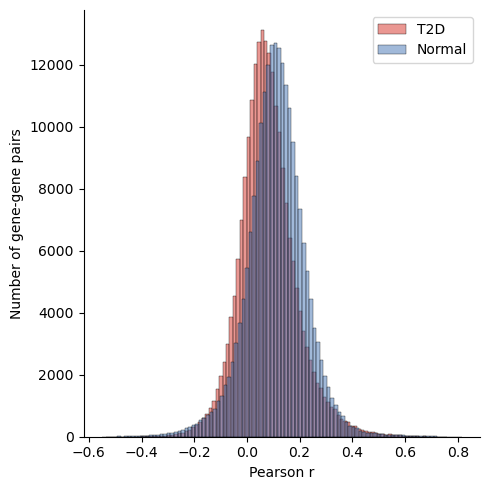

In [7]:
# Plot distributions
plt.figure(figsize=(5, 5))

sns.histplot(
    r_t2d,
    bins=100,
    stat="count",
    kde=False,
    alpha=0.5,
    label="T2D",
    color='#d73027'
    
)

sns.histplot(
    r_normal,
    bins=100,
    stat="count",
    kde=False,
    alpha=0.5,
    label="Normal",
    color='#4575b4'
)



plt.xlabel("Pearson r")
plt.ylabel("Number of gene-gene pairs")
#plt.title("Gene-gene correlation distribution")
plt.legend()
sns.despine()
plt.tight_layout()
plt.savefig('Figure1/Pearson_distribution.png')
plt.savefig('Figure1/Pearson_distribution.svg')
plt.show()

In [8]:
np.median(np.abs(r_t2d))

np.float64(0.08386952125568334)

In [9]:
np.median(np.abs(r_normal))

np.float64(0.11777469419714694)

# dGCNA

In [10]:

results = run_dgcna_analysis(
    adata, 
    genes=ndcg_genes,  # optional: subset to specific genes
    disease_col='Disease',
    t2d_value='T2D',
    ctrl_value='normal',
    n_bootstrap=512,
    threshold=0.975
)


Using 664 / 671 specified genes

=== Step 1: Computing LMM residuals (per condition) ===
Cells: 582, donors: 9, genes: 664
Cells: 456, donors: 8, genes: 664

=== Step 2: Building differential network ===
T2D cells: 582, Control cells: 456

=== Step 3: Bootstrap filtering ===


Random donor groups (with replacement): 100%|████████████████████████████████████████| 512/512 [01:37<00:00,  5.25it/s]

Significant edges: 24598 / 220116 (11.2%)


In [11]:
'''
# Access results
results['filtered_net']  # Bootstrap-filtered differential network
results['corr_t2d']      # T2D correlation matrix
results['corr_ctrl']     # Control correlation matrix
results['diff_net']      # Raw differential network (T2D - Ctrl)
results['p_values']      # Bootstrap significance
'''

"\n# Access results\nresults['filtered_net']  # Bootstrap-filtered differential network\nresults['corr_t2d']      # T2D correlation matrix\nresults['corr_ctrl']     # Control correlation matrix\nresults['diff_net']      # Raw differential network (T2D - Ctrl)\nresults['p_values']      # Bootstrap significance\n"

<Axes: xlabel='gene_name', ylabel='gene_name'>

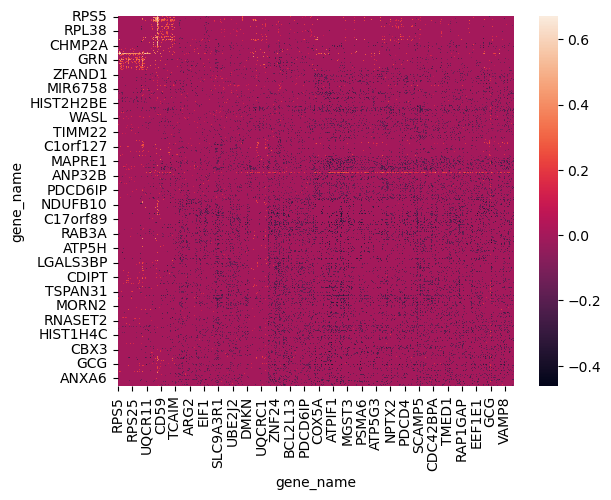

In [12]:
sns.heatmap(results['filtered_net'])

In [13]:
corr=results['filtered_net'].copy()

In [14]:
logfc_df = pd.read_csv("Integrated_logFC.csv", index_col=0)


In [15]:
# Assuming:
# - corr: pd.DataFrame (genes x genes) - differential correlation matrix (Δr = T2D - Ctrl)
# - logfc_df: pd.DataFrame with gene names as index and 'logFC' column

# Get upper triangle indices (avoid duplicates and diagonal)
genes = corr.index.tolist()
n = len(genes)

rows = []
for i in range(n):
    for j in range(i+1, n):
        g1, g2 = genes[i], genes[j]
        r_t2d =  results['corr_t2d'].iloc[i, j]
        r_ctrl =  results['corr_ctrl'].iloc[i, j]
        delta_r = results['filtered_net'].iloc[i, j]
        
        # Get |logFC| for each gene
        lfc1 = abs(logfc_df.loc[g1, 'logFC']) if g1 in logfc_df.index else np.nan
        lfc2 = abs(logfc_df.loc[g2, 'logFC']) if g2 in logfc_df.index else np.nan
        
        rows.append({
            'gene1': g1,
            'gene2': g2,
            'r_t2d': r_t2d,
            'r_ctrl': r_ctrl,
            'delta_r': delta_r,
            'abs_delta_r': abs(delta_r),
            'max_logFC': max(np.abs(lfc1), np.abs(lfc2)),
            'min_logFC': min(np.abs(lfc1), np.abs(lfc2)),
            'mean_logFC': (lfc1 + lfc2) / 2,
        })

edge_df = pd.DataFrame(rows).dropna()

In [16]:
edge_df.to_csv('Edges_data.csv')

In [17]:
edge_df

,gene1,gene2,r_t2d,r_ctrl,delta_r,abs_delta_r,max_logFC,min_logFC,mean_logFC
0,RPS5,RPL11,0.442609,0.400233,0.000000,0.000000,0.185737,0.173918,0.179827
1,RPS5,RPL35A,0.355984,0.392129,0.000000,0.000000,0.317574,0.173918,0.245746
2,RPS5,GABARAP,0.386887,0.425393,0.000000,0.000000,0.173918,0.016436,0.095177
3,RPS5,DSTN,0.323610,0.334359,0.000000,0.000000,0.495335,0.173918,0.334626
4,RPS5,OAZ1,0.258910,0.255940,0.000000,0.000000,0.173918,0.098966,0.136442
...,...,...,...,...,...,...,...,...,...
220111,LYRM9,UBE2N,0.109055,0.129411,0.000000,0.000000,0.465786,0.371339,0.418562
220112,LYRM9,DARS2,-0.024131,0.124720,-0.148851,0.148851,0.465786,0.434768,0.450277
220113,ACADM,UBE2N,0.137963,0.153360,0.000000,0.000000,0.371339,0.282444,0.326891
220114,ACADM,DARS2,0.073476,0.123510,0.000000,0.000000,0.434768,0.282444,0.358606


In [18]:
# ── Summary statistics for dGCNA results ──
n_total = len(edge_df)
n_sig = (edge_df['abs_delta_r'] > 0).sum()
pct_sig = 100 * n_sig / n_total

print(f"Total gene pairs: {n_total}")
print(f"Significant edges (|Δr| > 0 after filtering): {n_sig} ({pct_sig:.1f}%)")

sig = edge_df[edge_df['abs_delta_r'] > 0]
nonsig = edge_df[edge_df['abs_delta_r'] == 0]

print(f"\n── Significant edges ──")
print(f"|Δr| median: {sig['abs_delta_r'].median():.3f}, mean: {sig['abs_delta_r'].mean():.3f}")
print(f"|Δr| range: [{sig['abs_delta_r'].min():.3f}, {sig['abs_delta_r'].max():.3f}]")
print(f"|Δr| Q1/Q3: {sig['abs_delta_r'].quantile(0.25):.3f} / {sig['abs_delta_r'].quantile(0.75):.3f}")

print(f"\nHyper-correlated in T2D (Δr > 0): {(sig['delta_r'] > 0).sum()} ({100*(sig['delta_r']>0).mean():.1f}%)")
print(f"De-correlated in T2D (Δr < 0):   {(sig['delta_r'] < 0).sum()} ({100*(sig['delta_r']<0).mean():.1f}%)")

print(f"\n── Correlation magnitudes ──")
print(f"|r_ctrl| median: {sig['r_ctrl'].abs().median():.3f}, mean: {sig['r_ctrl'].abs().mean():.3f}")
print(f"|r_t2d| median:  {sig['r_t2d'].abs().median():.3f}, mean: {sig['r_t2d'].abs().mean():.3f}")

# How many sig edges have weak correlations in BOTH conditions?
weak_both = ((sig['r_ctrl'].abs() < 0.2) & (sig['r_t2d'].abs() < 0.2)).sum()
print(f"\nSig edges with |r| < 0.2 in BOTH conditions: {weak_both} ({100*weak_both/len(sig):.1f}%)")

weak_either = ((sig['r_ctrl'].abs() < 0.1) | (sig['r_t2d'].abs() < 0.1)).sum()
print(f"Sig edges with |r| < 0.1 in at least one condition: {weak_either} ({100*weak_either/len(sig):.1f}%)")

# Number of unique genes involved in significant edges
sig_genes = set(sig['gene1']).union(set(sig['gene2']))
print(f"\nUnique genes in significant edges: {len(sig_genes)}")

Total gene pairs: 220116
Significant edges (|Δr| > 0 after filtering): 24598 (11.2%)

── Significant edges ──
|Δr| median: 0.168, mean: 0.175
|Δr| range: [0.051, 0.670]
|Δr| Q1/Q3: 0.140 / 0.202

Hyper-correlated in T2D (Δr > 0): 2293 (9.3%)
De-correlated in T2D (Δr < 0):   22305 (90.7%)

── Correlation magnitudes ──
|r_ctrl| median: 0.165, mean: 0.168
|r_t2d| median:  0.034, mean: 0.047

Sig edges with |r| < 0.2 in BOTH conditions: 17037 (69.3%)
Sig edges with |r| < 0.1 in at least one condition: 23562 (95.8%)

Unique genes in significant edges: 664


In [19]:
# ── Summary statistics + plots for dGCNA results ──

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

n_total = len(edge_df)
n_sig = (edge_df['abs_delta_r'] > 0).sum()
pct_sig = 100 * n_sig / n_total

sig = edge_df[edge_df['abs_delta_r'] > 0]
nonsig = edge_df[edge_df['abs_delta_r'] == 0]

print(f"Total gene pairs: {n_total}")
print(f"Significant edges (|Δr| > 0 after filtering): {n_sig} ({pct_sig:.1f}%)")
print(f"|Δr| median: {sig['abs_delta_r'].median():.3f}, mean: {sig['abs_delta_r'].mean():.3f}")
print(f"|Δr| range: [{sig['abs_delta_r'].min():.3f}, {sig['abs_delta_r'].max():.3f}]")
print(f"Hyper (Δr>0): {(sig['delta_r']>0).sum()} ({100*(sig['delta_r']>0).mean():.1f}%)")
print(f"De   (Δr<0): {(sig['delta_r']<0).sum()} ({100*(sig['delta_r']<0).mean():.1f}%)")
print(f"|r_ctrl| median: {sig['r_ctrl'].abs().median():.3f}")
print(f"|r_t2d| median:  {sig['r_t2d'].abs().median():.3f}")
weak_both = ((sig['r_ctrl'].abs() < 0.2) & (sig['r_t2d'].abs() < 0.2)).sum()
print(f"Sig edges with |r|<0.2 in BOTH: {weak_both} ({100*weak_both/len(sig):.1f}%)")
sig_genes = set(sig['gene1']).union(set(sig['gene2']))
print(f"Unique genes in sig edges: {len(sig_genes)}")


Total gene pairs: 220116
Significant edges (|Δr| > 0 after filtering): 24598 (11.2%)
|Δr| median: 0.168, mean: 0.175
|Δr| range: [0.051, 0.670]
Hyper (Δr>0): 2293 (9.3%)
De   (Δr<0): 22305 (90.7%)
|r_ctrl| median: 0.165
|r_t2d| median:  0.034
Sig edges with |r|<0.2 in BOTH: 17037 (69.3%)
Unique genes in sig edges: 664


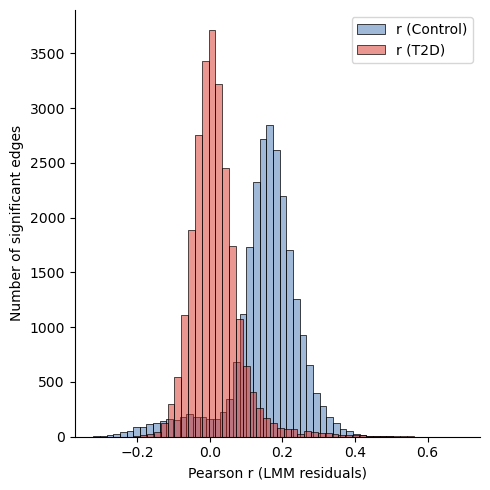

In [20]:
# Distribution of r_ctrl and r_t2d for significant edges

fig, ax = plt.subplots(figsize=(5, 5))

sns.histplot(sig['r_ctrl'], bins=50, alpha=0.5, color='#4575b4', label='r (Control)', ax=ax)
sns.histplot(sig['r_t2d'], bins=50, alpha=0.5, color='#d73027', label='r (T2D)', ax=ax)

ax.set_xlabel('Pearson r (LMM residuals)')
ax.set_ylabel('Number of significant edges')

ax.legend()
sns.despine()
plt.tight_layout()
plt.savefig('Figure1/r_distribution.png')
plt.savefig('Figure1/r_distribution.svg')
plt.show()

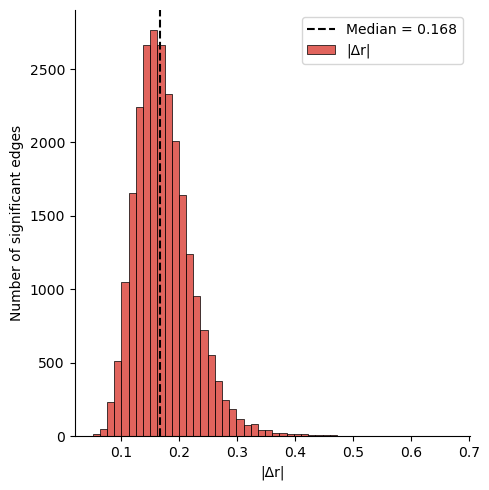

In [21]:
# Distribution of |Δr| for significant edges
fig, ax = plt.subplots(figsize=(5, 5))

sns.histplot(sig['abs_delta_r'], bins=50, color='#d73027', label='|Δr|', ax=ax)

ax.axvline(sig['abs_delta_r'].median(), color='black', lw=1.5, ls='--',
           label=f'Median = {sig["abs_delta_r"].median():.3f}')
ax.set_xlabel('|Δr|')
ax.set_ylabel('Number of significant edges')
ax.legend()
sns.despine()
plt.savefig('Figure1/delta_r.png')
plt.savefig('Figure1/delta_r.svg')
plt.tight_layout()


Saved dgcna_summary.png/.pdf


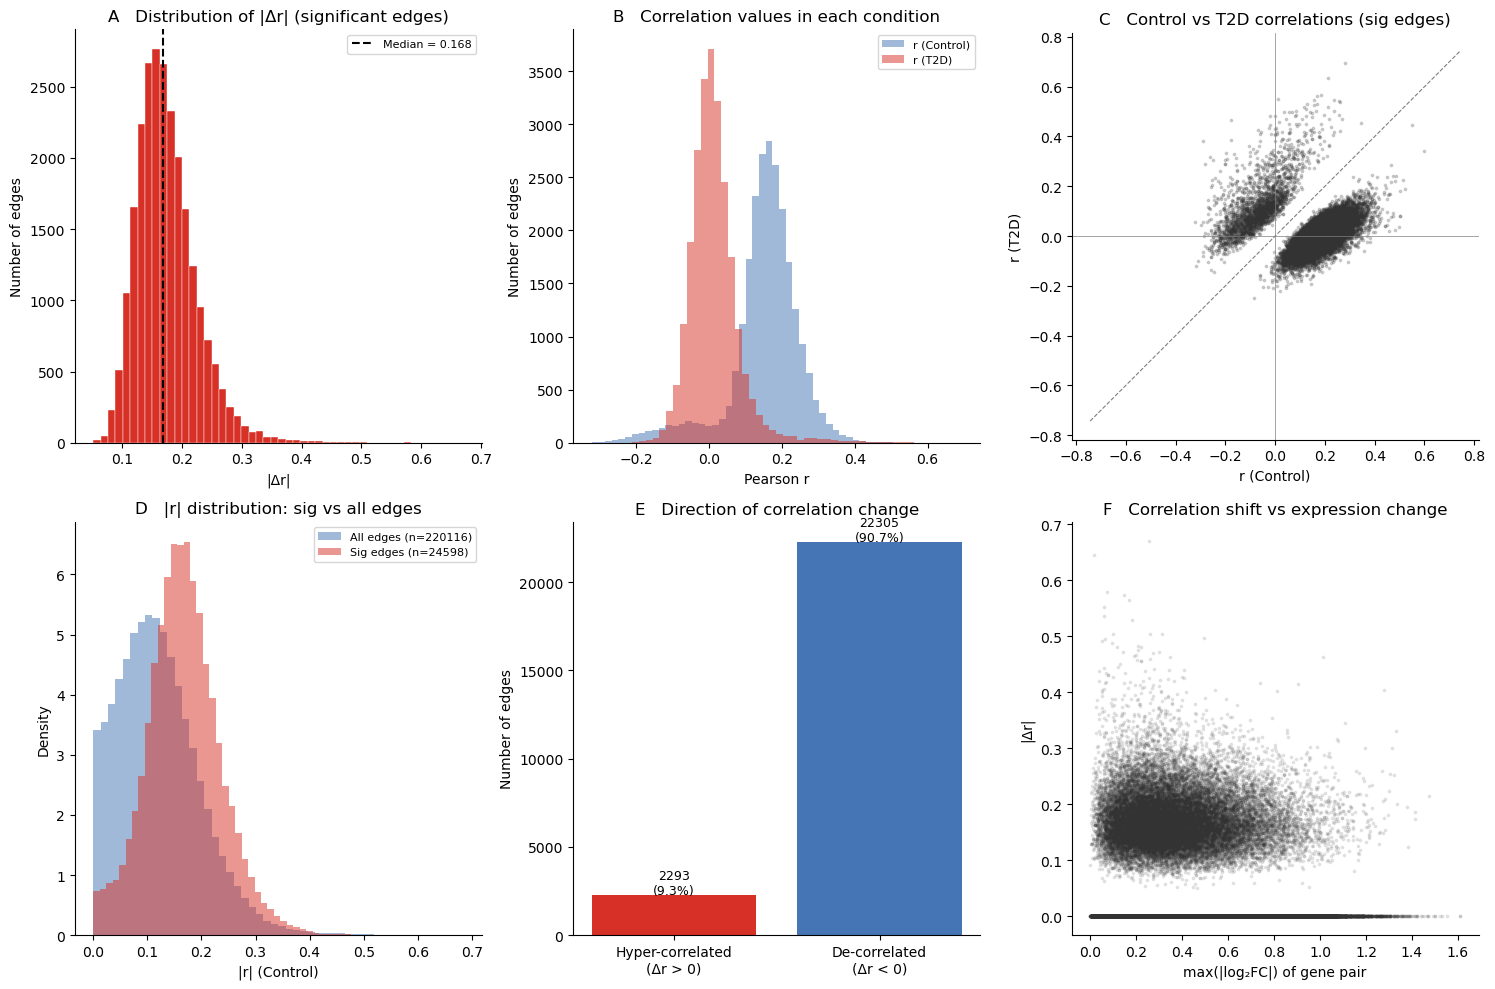

In [22]:

# ── Plots ──
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# A: Distribution of |Δr| for significant edges
ax = axes[0, 0]
ax.hist(sig['abs_delta_r'], bins=50, color='#d73027', edgecolor='white', linewidth=0.3)
ax.axvline(sig['abs_delta_r'].median(), color='black', lw=1.5, ls='--',
           label=f'Median = {sig["abs_delta_r"].median():.3f}')
ax.set_xlabel('|Δr|')
ax.set_ylabel('Number of edges')
ax.set_title('A   Distribution of |Δr| (significant edges)')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# B: Distribution of r_ctrl and r_t2d for significant edges
ax = axes[0, 1]
ax.hist(sig['r_ctrl'], bins=50, alpha=0.5, color='#4575b4', label='r (Control)')
ax.hist(sig['r_t2d'], bins=50, alpha=0.5, color='#d73027', label='r (T2D)')
ax.set_xlabel('Pearson r')
ax.set_ylabel('Number of edges')
ax.set_title('B   Correlation values in each condition')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# C: Scatter r_ctrl vs r_t2d (significant edges)
ax = axes[0, 2]
ax.scatter(sig['r_ctrl'], sig['r_t2d'], alpha=0.2, s=3, color='#333333')
lim = max(abs(sig['r_ctrl']).max(), abs(sig['r_t2d']).max()) + 0.05
ax.plot([-lim, lim], [-lim, lim], 'k--', lw=0.8, alpha=0.5)
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.set_xlabel('r (Control)')
ax.set_ylabel('r (T2D)')
ax.set_title('C   Control vs T2D correlations (sig edges)')
ax.spines[['top', 'right']].set_visible(False)
ax.set_aspect('equal')

# D: Distribution of |r| in significant vs all edges
ax = axes[1, 0]
ax.hist(edge_df['r_ctrl'].abs(), bins=50, alpha=0.5, density=True,
        color='#4575b4', label=f'All edges (n={n_total})')
ax.hist(sig['r_ctrl'].abs(), bins=50, alpha=0.5, density=True,
        color='#d73027', label=f'Sig edges (n={n_sig})')
ax.set_xlabel('|r| (Control)')
ax.set_ylabel('Density')
ax.set_title('D   |r| distribution: sig vs all edges')
ax.legend(fontsize=8)
ax.spines[['top', 'right']].set_visible(False)

# E: Hyper vs de-correlation pie/bar
ax = axes[1, 1]
n_hyper = (sig['delta_r'] > 0).sum()
n_de = (sig['delta_r'] < 0).sum()
ax.bar(['Hyper-correlated\n(Δr > 0)', 'De-correlated\n(Δr < 0)'],
       [n_hyper, n_de], color=['#d73027', '#4575b4'])
ax.set_ylabel('Number of edges')
ax.set_title('E   Direction of correlation change')
ax.spines[['top', 'right']].set_visible(False)
for i, v in enumerate([n_hyper, n_de]):
    ax.text(i, v + 50, f'{v}\n({100*v/len(sig):.1f}%)', ha='center', fontsize=9)

# F: |Δr| vs max_logFC
ax = axes[1, 2]
ax.scatter(edge_df['mean_logFC'], edge_df['abs_delta_r'], alpha=0.1, s=3, color='#333333')
ax.set_xlabel('max(|log₂FC|) of gene pair')
ax.set_ylabel('|Δr|')
ax.set_title('F   Correlation shift vs expression change')
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('dgcna_summary.png', dpi=200, bbox_inches='tight')
plt.savefig('dgcna_summary.svg', bbox_inches='tight')
print("\nSaved dgcna_summary.png/.pdf")
plt.show()